In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Обробка документів

In [49]:
data_document_files = {
    "court_2020": "edrsr_data_2020",
    "court_2021": "edrsr_data_2021",
    "court_2022": "edrsr_data_2022",
    "court_2023": "edrsr_data_2023",
    "court_2024": "edrsr_data_2024",
    "court_2025": "edrsr_data_2025",
}

In [60]:
categories_df = pd.read_csv("edrsr_data_2025/cause_categories.csv", sep="\t")

In [50]:
court_2020_df = pd.read_csv(data_document_files["court_2020"] + "/documents.csv", sep="\t")
court_2021_df = pd.read_csv(data_document_files["court_2021"] + "/documents.csv", sep="\t")
court_2022_df = pd.read_csv(data_document_files["court_2022"] + "/documents.csv", sep="\t")
court_2023_df = pd.read_csv(data_document_files["court_2023"] + "/documents.csv", sep="\t")
court_2024_df = pd.read_csv(data_document_files["court_2024"] + "/documents.csv", sep="\t")
court_2025_df = pd.read_csv(data_document_files["court_2025"] + "/documents.csv", sep="\t")

In [52]:
court_2025_df.head()

,doc_id,court_code,judgment_code,justice_kind,category_code,cause_num,adjudication_date,receipt_date,judge,doc_url,status,date_publ
0,124185778,9921,5,4.0,40117.0,320/24247/24,2024-12-31 00:00:00+02,2025-01-01 00:00:00+02,Ханова Р.Ф.,https://od.reyestr.court.gov.ua/files/62/094c8...,1,2025-01-01 00:00:00+02
1,124185776,9921,5,4.0,40117.0,240/19237/23,2024-12-31 00:00:00+02,2025-01-01 00:00:00+02,Ханова Р.Ф.,https://od.reyestr.court.gov.ua/files/62/83844...,1,2025-01-01 00:00:00+02
2,124176959,2601,2,5.0,41237.0,752/22764/24,2024-12-20 00:00:00+02,2025-01-01 00:00:00+02,Вдовиченко О. О.,https://od.reyestr.court.gov.ua/files/62/c5f8d...,1,2025-01-01 00:00:00+02
3,124177546,2521,5,1.0,40394.0,746/633/24,2024-12-31 00:00:00+02,2025-01-01 00:00:00+02,Нагорна Н. Г.,NaN,0,2025-01-01 00:00:00+02
4,124185779,9921,5,4.0,40140.0,280/9312/23,2024-12-31 00:00:00+02,2025-01-01 00:00:00+02,Ханова Р.Ф.,https://od.reyestr.court.gov.ua/files/62/68858...,1,2025-01-01 00:00:00+02


In [56]:
categories_df

,category_code,name
0,2036,Захоплення заручників
1,3017,звільнення з публічної служби
2,4095,Землекористування
3,2041,Зловживання військовою службовою особою владою...
4,2076,Зловживання владою або службовим становищем
...,...,...
4101,13090,про відшкодування шкоди
4102,13091,грошові вимоги кредитора до боржника
4103,13092,"майнові спори, стороною в яких є боржник, з них:"
4104,13093,затвердження плану санації або плану реструкту...


Найчастіші категорії порушень

In [63]:
%%sql
WITH category_counts AS (
    SELECT category_code, COUNT(category_code) as category_quantity
    FROM court_2025_df
    GROUP BY category_code
    ORDER BY category_quantity DESC
)
SELECT *
FROM category_counts
LEFT JOIN categories_df ON category_counts.category_code = categories_df.category_code

,category_code,category_quantity,category_code_1,name
0,40346.0,678737,40346,"позики, кредиту, банківського вкладу, з них"
1,40348.0,436814,40348,споживчого кредиту
2,40149.0,436797,40149,"осіб, звільнених з публічної служби"
3,40148.0,386324,40148,загальнообов’язкового державного пенсійного ст...
4,40394.0,375972,40394,Справи щодо стягнення заборгованості за оплату...
...,...,...,...,...
1933,5552.0,1,5552,"Справи зі спорів щодо оскарження актів, дій чи..."
1934,12826.0,1,12826,щодо володіння чужим майном
1935,41001.0,1,41001,Порушення правил ведення первинного обліку та ...
1936,11684.0,1,11684,плати за землю


In [65]:
df_categories_quantity.head(50)

,category_code,category_quantity,category_code_1,name
0,40346.0,678737,40346,"позики, кредиту, банківського вкладу, з них"
1,40348.0,436814,40348,споживчого кредиту
2,40149.0,436797,40149,"осіб, звільнених з публічної служби"
3,40148.0,386324,40148,загальнообов’язкового державного пенсійного ст...
4,40394.0,375972,40394,Справи щодо стягнення заборгованості за оплату...
5,40376.0,284808,40376,про розірвання шлюбу
6,40469.0,231752,40469,тимчасовий доступ до речей і документів
7,41090.0,178635,41090,Керування транспортними засобами або суднами о...
8,40343.0,161678,40343,надання послуг
9,40151.0,131785,40151,"громадян, які постраждали внаслідок Чорнобильс..."


# Візуалізація кількості справ та матеріалів щодо їх динаміки опрацювань судами

Графік, що відображає динаміку справ по наступним категоріям у кількісному та відсотковому форматах. Дані беруться з 2020 по 2025 роки.

Типи динамік(місцеві та апеляційні суди):
- Кількість справ та матеріалів, що перебували на розгляді у судах
- Кількість справ та матеріалів, що надійшли на розгляд до судів
- Кількість справ та матеріалів розглянутих судами
- Кількість справ та матеріалів <strong>НЕ</strong> розглянуті судами
- Ефективність здійснення правосуддя судами

## Заповнення даними

`2.1` - кількість справ, що надійшли на розгляд до судів

In [3]:
court_2_1_taken = [
    (3_199_752, 3_730_037), # 2021
    (3_918_432, 2_537_114),
    (2_567_114, 4_063_353),
    (4_063_353, 4_096_499),
    (4_096_499, 4_397_098), # 2025
]

court_2_1_app = [
    (278_457, 332_130), # 2021
    (332_130, 224_650),
    (224_650, 288_730),
    (288_730, 326_307),
    (326_307, 420_892),
]

`1.1` - кількість справ, що перебували на розгляді у судах

In [2]:
court_1_1_pending = [
    (3_223_428, 3_585_213), # (_2020, _2021)
    (4_556_521, 3_282_175),
    (3_282_175, 4_622_827),
    (4_622_827, 4_790_485),
    (4_790_485, 5_172_363), # (_2024, _2025)
]

court_1_1_app = [
    (375_383, 383_551),
    (396_458, 300_493),
    (300_493, 366_446),
    (366_446, 409_265),
    (409_265, 517_768),
]

`3.1` - кількість справ та матеріалів, розглянутих судами

In [4]:
court_3_1_processed = [
    (3_048_734, 3_576_440),
    (3_764_903, 2_675_004),
    (2_675_004, 3_910_346),
    (3_910_346, 3_983_480),
    (3_983_480, 4_172_512),
]

court_3_1_app = [
    (263_869, 314_714),
    (314_714, 223_028),
    (223_028, 283_180),
    (283_180, 312_168),
    (312_168, 359_871),
]

`4.1` - кількість справ не розглянуті судами

In [6]:
court_4_1_unprocessed = [
    (538_751, 580_152),
    (791_618, 607_171),
    (607_171, 712_481),
    (712_481, 807_005),
    (807_005, 999_851),
]

court_4_1_app = [
    (37_458, 43_401),
    (81_744, 77_465),
    (77_465, 83_266),
    (83_226, 97_097),
    (97_097, 157_897),
]

## Створення графіків

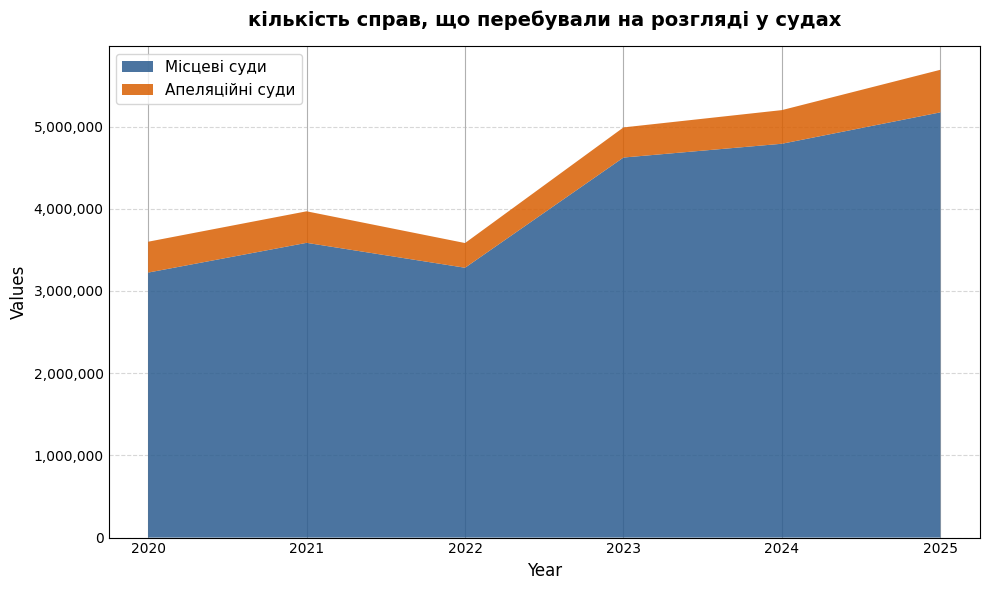

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the data from your arrays
x = np.arange(2020, 2026, 1)
ay = [court_1_1_pending[0][0]] + [el[1] for el in court_1_1_pending]
by = [court_1_1_app[0][0]] + [el[1] for el in court_1_1_app]

plt.figure(figsize=(10, 6))

plt.stackplot(x, ay, by,
              labels=['Місцеві суди', 'Апеляційні суди'],
              colors=['#2b5c8f', '#d95f02'],
              alpha=0.85)

plt.title('кількість справ, що перебували на розгляді у судах', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.xticks(x)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('figures/court_stat_1.1.png', dpi=300, bbox_inches='tight')
plt.show()

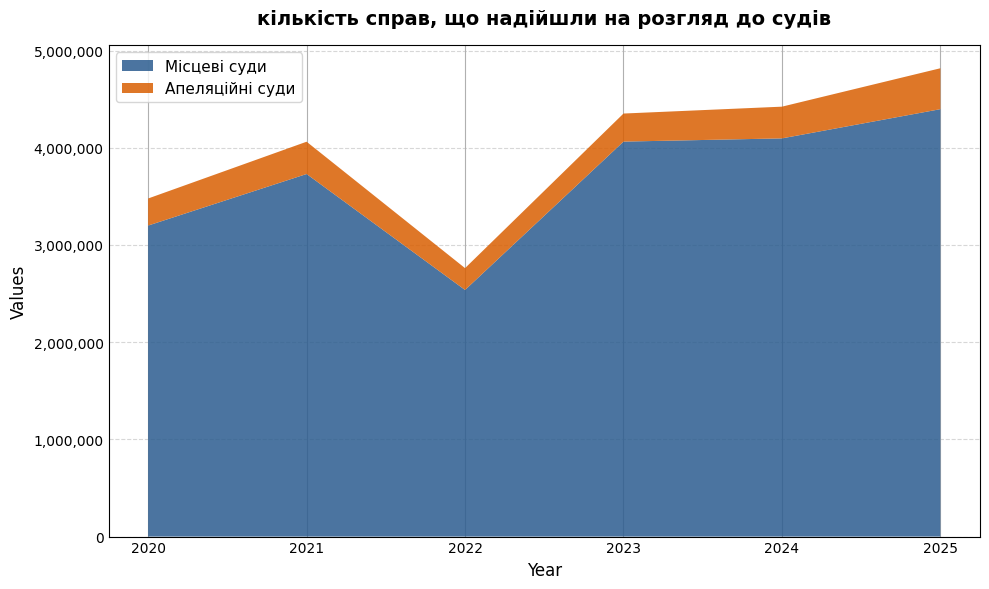

In [67]:
x = np.arange(2020, 2026, 1)
ay = [court_2_1_taken[0][0]] + [el[1] for el in court_2_1_taken]
by = [court_2_1_app[0][0]] + [el[1] for el in court_2_1_app]

plt.figure(figsize=(10, 6))

plt.stackplot(x, ay, by,
              labels=['Місцеві суди', 'Апеляційні суди'],
              colors=['#2b5c8f', '#d95f02'],
              alpha=0.85)

plt.title('кількість справ, що надійшли на розгляд до судів', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.xticks(x)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('figures/court_stat_2.1.png', dpi=300, bbox_inches='tight')
plt.show()

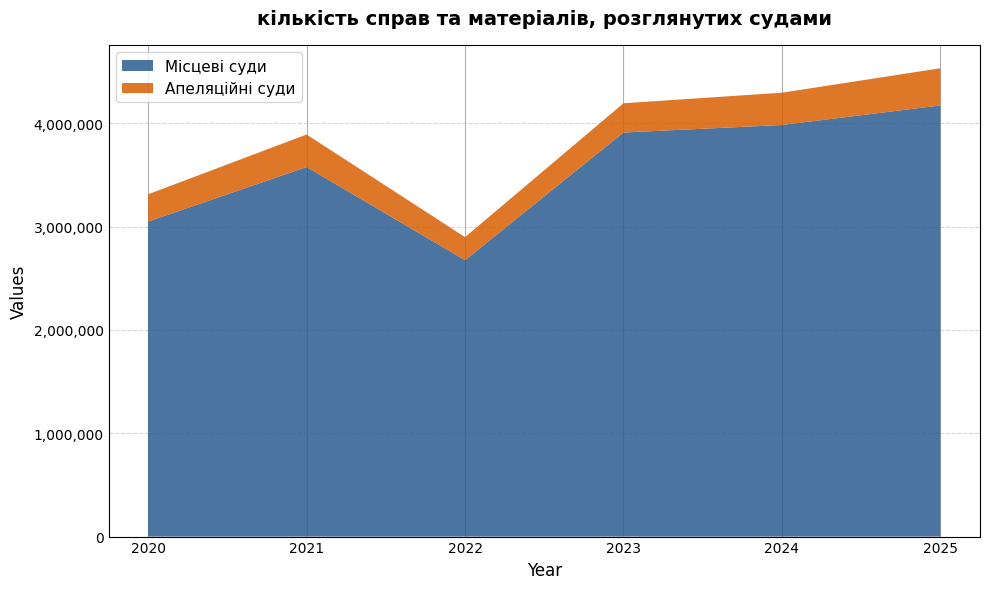

In [68]:
x = np.arange(2020, 2026, 1)
ay = [court_3_1_processed[0][0]] + [el[1] for el in court_3_1_processed]
by = [court_3_1_app[0][0]] + [el[1] for el in court_3_1_app]

plt.figure(figsize=(10, 6))

plt.stackplot(x, ay, by,
              labels=['Місцеві суди', 'Апеляційні суди'],
              colors=['#2b5c8f', '#d95f02'],
              alpha=0.85)

plt.title('кількість справ та матеріалів, розглянутих судами', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.xticks(x)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('figures/court_stat_3.1.png', dpi=300, bbox_inches='tight')
plt.show()

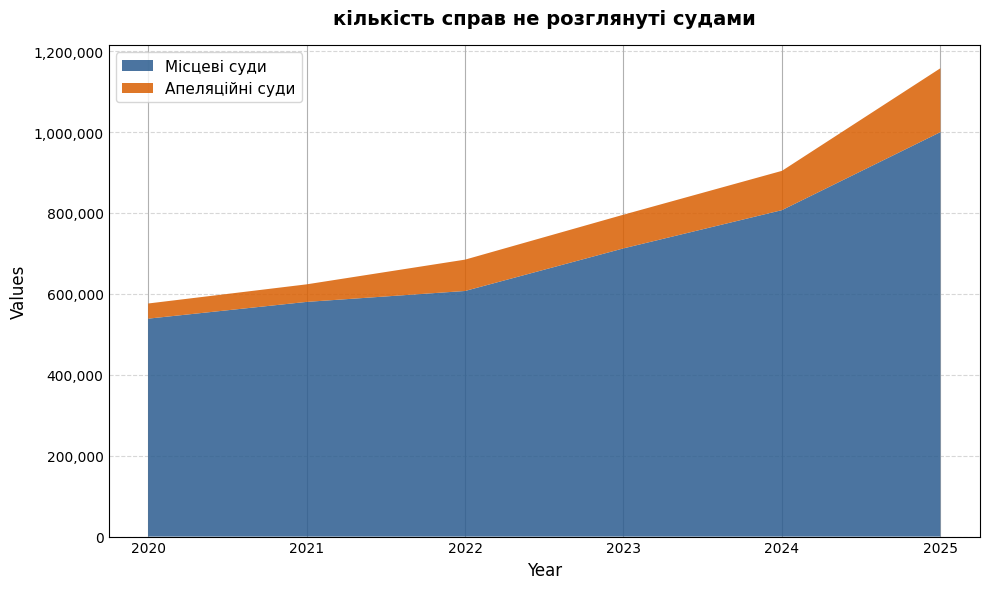

In [69]:
x = np.arange(2020, 2026, 1)
ay = [court_4_1_unprocessed[0][0]] + [el[1] for el in court_4_1_unprocessed]
by = [court_4_1_app[0][0]] + [el[1] for el in court_4_1_app]

plt.figure(figsize=(10, 6))

plt.stackplot(x, ay, by,
              labels=['Місцеві суди', 'Апеляційні суди'],
              colors=['#2b5c8f', '#d95f02'],
              alpha=0.85)

plt.title('кількість справ не розглянуті судами', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Values', fontsize=12)

plt.xticks(x)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig('figures/court_stat_4.1.png', dpi=300, bbox_inches='tight')
plt.show()